In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 1: Simulación de una EDE básica con método de EULER-Maruyama

Considere la ecuación diferencial estocástica: 
$$dX_t = \mu X_t dt + \sigma X_t dW_t , \hspace{0.3cm} X_0 = x_0$$
donde $W_t$ es un proceso de Wiener estándar, $\mu > 0 y \sigma > 0$

1. Simule la trayectoria de $X_t$ usando el método de Euler-Maruyana para $t \in [0,T]$, con T = 1 y un paso de tiempo $\Delta t = 0.01$. Use los parámetros:
$x_0 = 1, \mu = 0.5, \sigma = 0.2$

1. Calculamos el número de pasos como $N = \frac{T}{\Delta t}$
2. Se crea un arreglo para la serie $X_t$ de tamaño N + 1 para almacenar los pasos que se den en la serie.
3. Establecemos el primer valor de la serie como $X_0 = 1$
4. Partimos el intervalo de tiempo [0,1] para ver los pasos que se darán.
5. Se comienza el ciclo para simular el proceso estocástico:
    6. Generamos el incremento de Wiener, con distribución normal, con media cero y varianza $\sqrt{\Delta t}$
    7. Se calcula el siguiente paso sumando el paso anterior, con la forma de Euler-Maruyama:  $X[i+1]=X[i]+μX[i]Δt+σX[i]ΔW$
8. Se gráfica el proceso

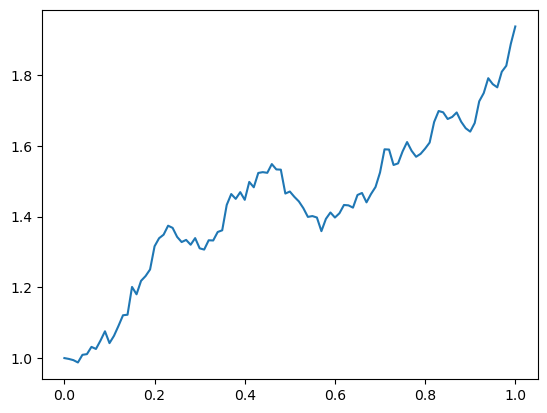

In [167]:
#Euler - Maruyama
# Método de Euler
# Parámetros
T = 1
dt = 0.01
x0 = 1
mu = 0.5 
sigma = 0.2 #desviación estándar (volatilidad)
N = int(T/dt)

#Paso 1:
X = np.zeros(N+1)  #Espacios para generar la serie Xt
X[0] = x0    #Valor la entrada 1 del arreglo
t = np.linspace(0,T,N+1)
#Paso 2: Simulación mediante euler
for i in range(N):   
    dw = np.random.normal(0,np.sqrt(dt))
    X[i+1] = X[i]+(mu * X[i] * dt)+ (sigma * X[i] * dw)

#Gráfico de la trayectoria de Xt con el método de Euler-Maruyana
plt.plot(t,X)



2. Repita la simulación para 10,000 trayectorias y estime el valor esperado $E[X_t]$. Compare con la solución teórica:
$$E[X_T] = x_0 e^{\mu T}$$

1. Calculamos el número de pasos como $N = \frac{T}{\Delta t}$
2. Se crea un arreglo para la serie $X_t$ de tamaño N + 1 para almacenar los pasos que se den en la serie.
3. Establecemos el primer valor de la serie como $X_0 = 1$
4. Partimos el intervalo de tiempo [0,1] para ver los pasos que se darán.
5. Se comienza el ciclo para simular el proceso estocástico:
    6. Generamos el incremento de Wiener, con distribución normal, con media cero y varianza $\sqrt{\Delta t}$
    7. Se calcula el siguiente paso sumando el paso anterior, con la forma de Euler-Maruyama:  $X[i+1]=X[i]+μX[i]Δt+σX[i]ΔW$
8. Se realizá este proceso 10,000, y el último paso de la serie $X_t$ se guarda en una lista
9. Se obtiene el promedio de la lista, con los últimos pasos de las series simuladas
10. Se calcula el resultado directo, para obtener el valor teórico

In [169]:
#Euler - Maruyama
# Método de Euler
# Parámetros
T = 1
dt = 0.01
x0 = 1
mu = 0.5 
sigma = 0.2 #desviación estándar (volatilidad)
N = int(T/dt)

lista = []
for j in range(10000): #Número de series simuladas
    # Paso 1:
    X = np.zeros(N+1)  #Espacios para generar la serie Xt
    X[0] = x0    #Valor la entrada 1 del arreglo
    t = np.linspace(0,T, N+1) #número de particiones (time)
    #Paso 2: Simulación mediante euler
    for i in range(N):   
        dw = np.random.normal(0,np.sqrt(dt))
        X[i+1] = X[i] + (mu * X[i] * dt)+ (sigma * X[i] * dw) #Se ingresa la EDE
    lista.append(X)
lista = np.array(lista)
X_media = np.mean(lista) #Cálculo de la media

print(f"Valor esperado simulado de E[X]:", X_media)
#Solución teórica
Teorica = x0 * np.exp(mu*T) #Valor esperado teórico
print(f"Valor esperado teórico de de E[X]:", Teorica)

Valor esperado simulado de E[X]: 1.294598807478348
Valor esperado teórico de de E[X]: 1.6487212707001282


## Ejercicio 2: Aplicación del método antitético para reducción de varianza 

Usando la misma EDE del ejercicio anterior: 
$$dX_t = \mu X_t dt + \sigma X_t dW_t , \hspace{0.3cm} X_0 = x_0$$
donde $W_t$ es un proceso de Wiener estándar, $\mu > 0 y \sigma > 0$
T = 1
$\Delta t = 0.01$
Parámetros:
$x_0 = 1$
$\mu = 0.5$
$\sigma = 0.2$
n = 10,000 

1. Introduzca el método antitético para simular pares de trayectorias:
    Para cada $W_{t}^{(1)} \sim N(0, \sqrt{\Delta t})$, genere su trayectoria     antitética, $W_{t}^{(2)} = -W_{t}^{(1)}$


1. Calculamos el número de pasos como $N = \frac{T}{\Delta t}$
2. Se crea un arreglo para la serie $X_t$ de tamaño N + 1 para almacenar los pasos que se den en la serie.
3. Establecemos el primer valor de la serie como $X_0 = 1$
4. Partimos el intervalo de tiempo [0,1] para ver los pasos que se darán.
5. Se comienza el ciclo para simular el proceso estocástico:
    6. Generamos el incremento de Wiener, con distribución normal, con media cero y varianza $\sqrt{\Delta t}$
    7. Generamos la serie $X_t$ sumando el paso anterior y el nuevo incremento con la respectiva EDE
    8. Generamos la serie antitética $Y_t$, donde dw, se pone en negativo
    9. Ambos pasos que se generan, se guardan en una sola lista
10. Se gráfican los valores que se generaron en la serie $X_t$ y $Y_t$
    



Valor esperado simulado de E[X]: 1.646427403514781
Valor esperado teórico de E[X]: 1.6487212707001282


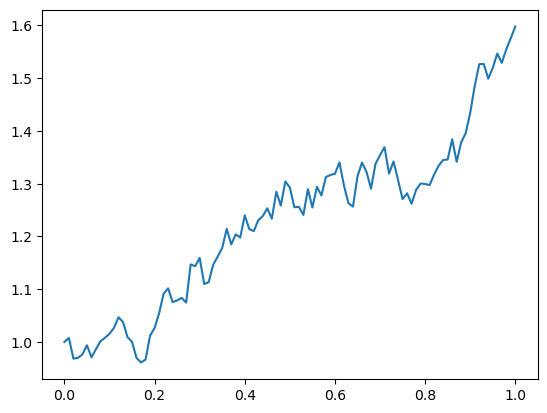

In [171]:
import numpy as np

# Parámetros
T = 1  # Tiempo total
dt = 0.01  # Tamaño del paso
x0 = 1  # Valor inicial
mu = 0.5  # Tasa de crecimiento
sigma = 0.2  # Volatilidad
N = int(T / dt)  # Número de pasos

# Lista para almacenar los resultados
lista = []

for j in range(10000):  
    # Inicializar series X_t y Y_t
    X = np.zeros(N + 1)
    Y = np.zeros(N + 1)
    X[0] = x0
    Y[0] = x0
    
    # Simulación mediante Euler-Maruyama con antítesis
    for i in range(N):
        dw = np.random.normal(0, np.sqrt(dt))  # Incremento del proceso de Wiener
        X[i + 1] = X[i] + mu * X[i] * dt + sigma * X[i] * dw
        Y[i + 1] = Y[i] + mu * Y[i] * dt - sigma * Y[i] * dw  # Antitético (-dw)
    
    # Agregar los últimos valores de las series simuladas a la lista
    lista.append(X[-1])
    lista.append(Y[-1])

# Convertir la lista a un arreglo numpy
lista = np.array(lista)

# Calcular el valor esperado simulado
X_media = np.mean(lista)
print(f"Valor esperado simulado de E[X]: {X_media}")

# Solución teórica
Teorica = x0 * np.exp(mu * T)
print(f"Valor esperado teórico de E[X]: {Teorica}")

#Gráfico de la trayectoria de Xt con el método de Euler-Maruyana
t = np.linspace(0,T,(N+1))
plt.plot(t,X)

Ajuste el esquema de Euler-Maruyama para calcular $X_{t}^{(1)}$ y $X_{t}^{(2)}$

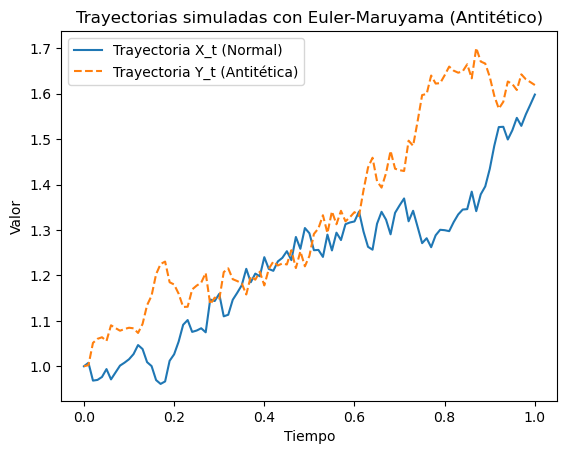

In [173]:
# Gráfica de trayectorias simuladas
t = np.linspace(0, T, N + 1)
plt.plot(t, X, label="Trayectoria X_t (Normal)")
plt.plot(t, Y, label="Trayectoria Y_t (Antitética)", linestyle="dashed")
plt.title("Trayectorias simuladas con Euler-Maruyama (Antitético)")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

2. Estime nuevamente $E[X_t]$ usando las trayectorias antitéticas. Compare la varianza de esta estimación con la obtenida en el ejercicio anterior.

1. Calculamos el número de pasos como $N = \frac{T}{\Delta t}$
2. Se crea un arreglo para la serie $X_t$ de tamaño N + 1 para almacenar los pasos que se den en la serie.
3. Establecemos el primer valor de la serie como $X_0 = 1$
4. Partimos el intervalo de tiempo [0,1] para ver los pasos que se darán.
5. Se comienza el ciclo para simular el proceso estocástico:
    6. Generamos el incremento de Wiener, con distribución normal, con media cero y varianza $\sqrt{\Delta t}$
    7. Generamos la serie $X_t$ sumando el paso anterior y el nuevo incremento con la respectiva EDE
    8. Generamos la serie antitética $Y_t$, donde dw, se pone en negativo
    9. Ambos pasos que se generan, se guardan en una sola lista
10. Se repite este proceso 10,000, y se almacena en otra lista el último valor de las series simuladas
11. De la lista que guarda los últimos valores de las series $X_t$ y $Y_t$ en una sola, para calcular la media de la lista
12. Se calcula la varianza de la serie $X_t$ con la serie que guarda los valores de las series $X_t$ y $Y_t$
    

In [175]:
import numpy as np

# Parámetros
T = 1  # Tiempo total
dt = 0.01  # Tamaño del paso
x0 = 1  # Valor inicial
mu = 0.5  # Tasa de crecimiento
sigma = 0.2  # Volatilidad
N = int(T / dt)  # Número de pasos

# Lista para almacenar los resultados
lista = []
lista2 = []
for j in range(10000):  
    # Inicio series X_t y Y_t
    X = np.zeros(N + 1)
    Y = np.zeros(N + 1)
    X[0] = x0
    Y[0] = x0
    
    # Simulación mediante Euler-Maruyama con antítesis
    for i in range(N):
        dw = np.random.normal(0, np.sqrt(dt))  # Incremento del proceso de Wiener
        X[i + 1] = X[i] + mu * X[i] * dt + sigma * X[i] * dw
        Y[i + 1] = Y[i] + mu * Y[i] * dt - sigma * Y[i] * dw  # Antitético (-dw)
    
    # Agregar los últimos valores de las series simuladas a la lista
    lista2.append(X[-1])
    lista.append(X[-1])
    lista.append(Y[-1])

# Convertir la lista a un arreglo numpy
lista = np.array(lista)
lista2 = np.array(lista2)

# Calcular valor de la varianza simulado
X_var = np.var(lista2)
X_var_a = np.var(lista)
print(f"Varianza simulaciones: {X_var}")
print(f"Varianza antitética: {X_var_a}")


Varianza simulaciones: 0.11004882055719488
Varianza antitética: 0.10894217138030815


In [176]:
import numpy as np

# Parámetros
T = 1  # Tiempo total
dt = 0.01  # Tamaño del paso
x0 = 1  # Valor inicial
mu = 0.5  # Tasa de crecimiento
sigma = 0.2  # Volatilidad
N = int(T / dt)  # Número de pasos

# Lista para almacenar los resultados
lista = []
lista2 = []
for j in range(10000):  
    # Inicio series X_t y Y_t
    X = np.zeros(N + 1)
    Y = np.zeros(N + 1)
    X[0] = x0
    Y[0] = x0
    
    # Simulación mediante Euler-Maruyama con antítesis
    for i in range(N):
        dw = np.random.normal(0, np.sqrt(dt))  # Incremento del proceso de Wiener
        X[i + 1] = X[i] + mu * X[i] * dt + sigma * X[i] * dw
        Y[i + 1] = Y[i] + mu * Y[i] * dt - sigma * Y[i] * dw  # Antitético (-dw)
    
    # Agregar los últimos valores de las series simuladas a la lista
    lista2.append(X[-1])
    lista.append(X[-1])
    lista.append(Y[-1])

# Convertir la lista a un arreglo numpy
lista = np.array(lista)
lista2 = np.array(lista2)

# Calcular valor de la varianza simulado
X_var = np.var(lista2)
X_var_a = np.var(lista)
print(f"Varianza simulaciones: {X_var}")
print(f"Varianza antitética: {X_var_a}")


Varianza simulaciones: 0.11009676580460291
Varianza antitética: 0.10996819010509348


# Problema 3
El problema plantea simular una ecuación diferencial estocástica (EDE) no lineal del tipo:

$$
dX_t = (\alpha - \beta X_t^2) dt + \sigma dW_t, \quad X_0 = x_0
$$

donde:
- $(\alpha)$, $(\beta)$ y $(\sigma)$ son parámetros del modelo.
- $(W_t)$ es un proceso de Wiener estándar, que introduce la componente estocástica.
- $(X_0)$ es la condición inicial.

El objetivo es estudiar la evolución de $(X_t)$ en el intervalo de tiempo $t \in [0, 2]$, comparando dos métodos de simulación: la simulación estándar y el método antitético, para 10,000 trayectorias.



#### 1. **Simulación del Movimiento Browniano**
El movimiento browniano se genera utilizando incrementos independientes con distribución normal de media cero y varianza proporcional al paso de tiempo $(\sqrt{dt})$. Estos incrementos se acumulan para construir la trayectoria $(B_t)$.

#### 2. **Simulación de la EDE no lineal (Método de Euler-Maruyama)**
Para resolver la EDE no lineal:

$$
dX_t = (\alpha - \beta X_t^2) dt + \sigma dW_t, \quad X_0 = x_0
$$

Se emplea el método de Euler-Maruyama, que calcula los valores discretos de $X_t$ en cada paso de tiempo $(dt)$:
- $(dW)$ es el incremento del movimiento browniano previamente generado.
- El valor de $X_{t+\Delta t}$ se actualiza como:
  $$
  X_{t+\Delta t} = X_t + (\alpha - \beta X_t^2) \Delta t + \sigma dW
  $$

#### 3. **Método Antitético**
Para reducir la varianza, el método antitético genera dos trayectorias simultáneamente:
- Una con incrementos $(dW)$ del movimiento browniano.
- Otra con incrementos opuestos $(-dW)$.
El promedio de ambas trayectorias $(X_{avg})$ mejora la precisión al compensar el efecto del ruido estocástico.


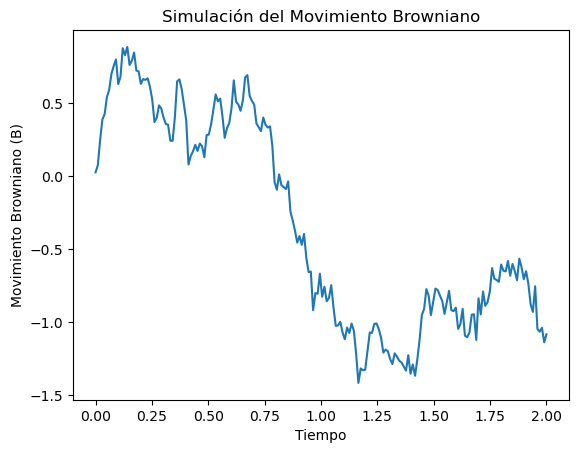

In [4]:
# Función para simular movimiento browniano
def simular_movimiento_browniano(T, N):
    dt = T / N  # Tamaño del intervalo de tiempo
    t = np.linspace(0, T, N)  # Vector de tiempos
    dB = np.random.normal(0, np.sqrt(dt), N)  # Incrementos aleatorios
    B = np.cumsum(dB)  # Movimiento browniano acumulado
    return t, B

# Parámetros
T = 2  # Tiempo total
N = int(T / 0.01)  # Número de pasos

# Simulación
t, B = simular_movimiento_browniano(T, N)

# Gráfico
plt.plot(t, B)
plt.title("Simulación del Movimiento Browniano")
plt.xlabel("Tiempo")
plt.ylabel("Movimiento Browniano (B)")
plt.show()

# Parte 2

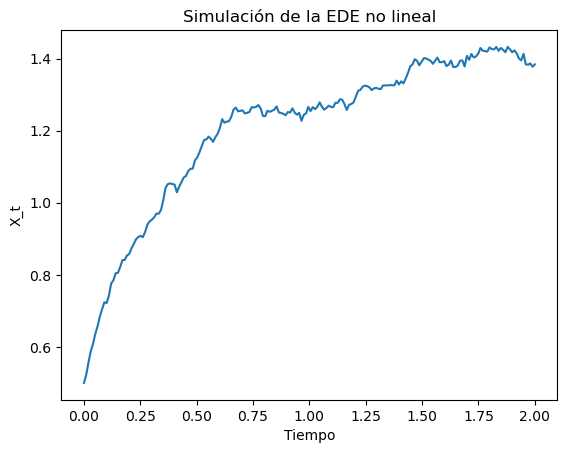

In [6]:
# Función para simular una EDE no lineal usando el movimiento Browniano
def simular_EDE(alpha, beta, sigma, x0, T, N, B):
    dt = T / N  # Tamaño del paso de tiempo
    X = np.zeros(N)  # Inicialización del vector de resultados
    X[0] = x0  # Condición inicial
    for i in range(1, N):
        dW = B[i] - B[i - 1]  # Incremento del movimiento Browniano
        # Ecuación diferencial estocástica (EDE):
        # Incremento determinista + término de ruido estocástico
        X[i] = X[i - 1] + (alpha - beta * X[i - 1]**2) * dt + sigma * dW
    return X

# Parámetros para la EDE
alpha = 2  # Tasa de crecimiento determinista
beta = 1  # Fuerza del término no lineal
sigma = 0.1  # Intensidad del ruido
x0 = 0.5  # Valor inicial

# Utilizamos el movimiento Browniano generado previamente en la Parte 1
X = simular_EDE(alpha, beta, sigma, x0, T, N, B)

# Visualización de la trayectoria simulada de la EDE
plt.plot(t, X)  # Graficamos el tiempo vs. la solución de la EDE
plt.title("Simulación de la EDE no lineal")
plt.xlabel("Tiempo")
plt.ylabel("X_t")
plt.show()



# Antiestetico

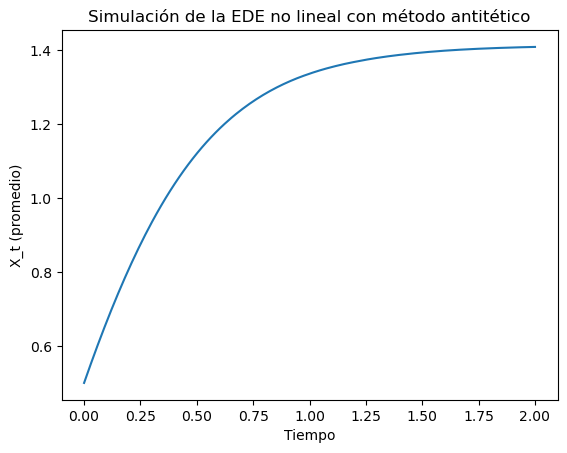

In [8]:
# Función para simular una EDE no lineal con el método antitético
def simular_EDE_antitetica(alpha, beta, sigma, x0, T, N, B):
    dt = T / N  # Tamaño del paso de tiempo
    X_std = np.zeros(N)  # Vector para la solución estándar
    X_ant = np.zeros(N)  # Vector para la solución antitética
    X_std[0], X_ant[0] = x0, x0  # Condición inicial para ambas trayectorias

    for i in range(1, N):
        dW = B[i] - B[i - 1]  # Incremento del movimiento Browniano
        # Trayectoria estándar
        X_std[i] = X_std[i - 1] + (alpha - beta * X_std[i - 1]**2) * dt + sigma * dW
        # Trayectoria antitética (invierte el signo del término estocástico)
        X_ant[i] = X_ant[i - 1] + (alpha - beta * X_ant[i - 1]**2) * dt - sigma * dW

    # Promedio de las trayectorias estándar y antitética
    X_avg = 0.5 * (X_std + X_ant)
    return X_avg

# Llamada a la simulación con método antitético
X_avg = simular_EDE_antitetica(alpha, beta, sigma, x0, T, N, B)

# Visualización del promedio de la EDE simulada
plt.plot(t, X_avg)
plt.title("Simulación de la EDE no lineal con método antitético")
plt.xlabel("Tiempo")
plt.ylabel("X_t (promedio)")
plt.show()



In [10]:
# Función para simular el precio de un activo
def simular_precio_activo(S0, r, sigma, T, N):
    dt = T / N  # Tamaño del paso de tiempo
    S = np.zeros(N+1)  # Vector para almacenar precios
    S[0] = S0  # Precio inicial
    for i in range(1, N+1):
        dW = np.random.normal(0, np.sqrt(dt))  # Incremento Browniano
        # Fórmula de Black-Scholes
        S[i] = S[i-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW)
    return S

# Función para calcular el precio de una opción
def calcular_precio_opcion(S, K, r, T, antitetico=False):
    if antitetico:
        # Generar trayectoria antitética para reducir varianza
        S_antithetic = S * np.exp(-2 * sigma * np.random.normal(0, np.sqrt(T), len(S)))
        # Promedio entre pagos estándar y antitéticos
        payoffs = 0.5 * (np.maximum(S[-1] - K, 0) + np.maximum(S_antithetic[-1] - K, 0))
    else:
        payoffs = np.maximum(S[-1] - K, 0)  # Pago estándar
    # Precio descontado al presente
    price = np.mean(payoffs) * np.exp(-r * T)
    return price

# Parámetros para la simulación
S0 = 100  # Precio inicial del activo
r = 0.05  # Tasa de interés libre de riesgo
sigma = 0.2  # Volatilidad
T = 1  # Tiempo hasta el vencimiento (1 año)
N = 1000  # Número de pasos
K = 110  # Precio de ejercicio
M = 10000  # Número de simulaciones

# Simular precios del activo
S = simular_precio_activo(S0, r, sigma, T, N)

# Calcular precio de la opción con los métodos estándar y antitético
precio_estandar = calcular_precio_opcion(S, K, r, T)  # Método estándar
precio_antitetico = calcular_precio_opcion(S, K, r, T, antitetico=True)  # Método antitético

# Mostrar resultados
print("Método Estándar - Precio de la Opción:", precio_estandar)
print("Método Antitético - Precio de la Opción:", precio_antitetico)


Método Estándar - Precio de la Opción: 3.148685575861478
Método Antitético - Precio de la Opción: 1.574342787930739


# Ejercicio 4

#### 1. **Modelo de Black-Scholes**
El problema considera la dinámica del precio de un activo $(S_t)$ bajo el modelo de Black-Scholes:

$$
dS_t = r S_t dt + \sigma S_t dW_t
$$

donde:
- $(S_0)$ es el precio inicial del activo.
- $(r)$ es la tasa libre de riesgo.
- $(\sigma)$ es la volatilidad.
- $(dW_t)$ es un incremento del movimiento browniano.

El precio de una opción de compra $(C)$ se calcula como:

$$
C = e^{-rT} \mathbb{E}[(S_T - K)^+]
$$

#### 2. **Simulación del Precio del Activo**
El precio del activo $(S_t)$ se simula utilizando el método de Euler-Maruyama. La fórmula discreta es:

$$
S_{t+\Delta t} = S_t \cdot \exp\left((r - 0.5 \sigma^2) \Delta t + \sigma \Delta W\right)
$$

Se genera un conjunto de trayectorias del precio del activo utilizando:
- Simulación estándar.
- Método antitético, generando trayectorias adicionales con incrementos opuestos $(-\Delta W)$ para reducir la varianza.

#### 3. **Cálculo del Precio de la Opción**
Para cada simulación:
- Se calculan los pagos $(\max(S_T - K, 0))$.
- Se aplica el descuento $e^{-rT}$ al promedio de los pagos para obtener el precio esperado de la opción.
- Se calcula la varianza de los pagos para evaluar la calidad de la estimación.

#### 4. **Método Milstein**
Se compara también con el método de Milstein, que mejora la precisión al incluir términos adicionales en la simulación. Sin embargo, para este problema, su aplicación no es estrictamente necesaria, pero sirve para validar las diferencias con Euler-Maruyama.





In [13]:
# Simula el precio del activo según el modelo de Black-Scholes
def simular_precio_activo(S0, r, sigma, T, N, antitetico=False):

    dt = T / N  # Tamaño del paso de tiempo
    S = np.zeros(N+1)  # Vector para almacenar precios simulados
    S[0] = S0  # Precio inicial
    if antitetico:
        S_ant = np.zeros(N+1)  # Vector para trayectoria antitética
        S_ant[0] = S0

    for i in range(1, N+1):
        dW = np.random.normal(0, np.sqrt(dt))  # Incremento Browniano
        S[i] = S[i-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW)  # Precio estándar
        if antitetico:
            S_ant[i] = S_ant[i-1] * np.exp((r - 0.5 * sigma**2) * dt - sigma * dW)  # Precio antitético

    return (S, S_ant) if antitetico else S

# Calcula el precio de la opción de compra
def calcular_precio_opcion(S, K, r, T, S_ant=None):

    if S_ant is not None:
        # Promedio de pagos estándar y antitéticos
        payoffs = 0.5 * (np.maximum(S[-1] - K, 0) + np.maximum(S_ant[-1] - K, 0))
    else:
        payoffs = np.maximum(S[-1] - K, 0)  # Pagos estándar

    # Verificación de valores inválidos
    if np.isnan(payoffs).any() or np.isinf(payoffs).any():
        print("Payoffs contain NaN or infinite values.")

    # Cálculo del precio descontado
    price = np.mean(payoffs) * np.exp(-r * T)
    # Cálculo de la varianza, si es aplicable
    variance = np.var(payoffs, ddof=1) if payoffs.size > 1 else 0
    variance *= np.exp(-2 * r * T)  # Descuento aplicado a la varianza

    return price, variance if np.isfinite(variance) else 0

# Parámetros del modelo y de la simulación
S0 = 100  # Precio inicial del activo
K = 110  # Precio de ejercicio de la opción
r = 0.05  # Tasa de interés libre de riesgo
sigma = 0.2  # Volatilidad
T = 1  # Tiempo hasta el vencimiento (1 año)
N = 1000  # Número de pasos en la simulación
M = 10000  # Número de simulaciones

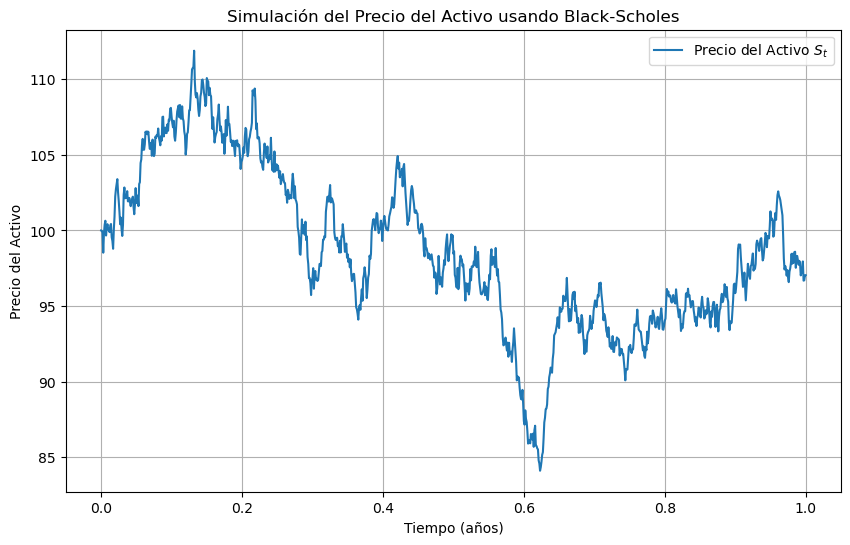

In [14]:
# Simulación del precio del activo
t = np.linspace(0, T, N+1)  # Vector de tiempo
S = simular_precio_activo(S0, r, sigma, T, N)  # Simulación del precio del activo

# Visualización del precio del activo
plt.figure(figsize=(10, 6))  # Tamaño de la figura
plt.plot(t, S, label='Precio del Activo $S_t$')  # Gráfico del precio del activo
plt.title('Simulación del Precio del Activo usando Black-Scholes')  # Título del gráfico
plt.xlabel('Tiempo (años)')  # Etiqueta del eje x
plt.ylabel('Precio del Activo')  # Etiqueta del eje y
plt.legend()  # Leyenda
plt.grid(True)  # Mostrar la cuadrícula
plt.show()  # Mostrar el gráfico

In [18]:
# Simulación estándar
precio_estandar, varianza_estandar = calcular_precio_opcion(S, K, r, T)

# Simulación con método antitético
S, S_ant = simular_precio_activo(S0, r, sigma, T, N, antitetico=True)
precio_antitetico, varianza_antitetica = calcular_precio_opcion(S, K, r, T, S_ant)

# Resultados de ambas simulaciones
print("Simulación Estándar - Precio: {:.2f}, Varianza: {:.20f}".format(precio_estandar, varianza_estandar))
print("Método Antitético - Precio: {:.2f}, Varianza: {:.20f}".format(precio_antitetico, varianza_antitetica))


Simulación Estándar - Precio: 1.33, Varianza: 0.00000000000000000000
Método Antitético - Precio: 7.04, Varianza: 0.00000000000000000000


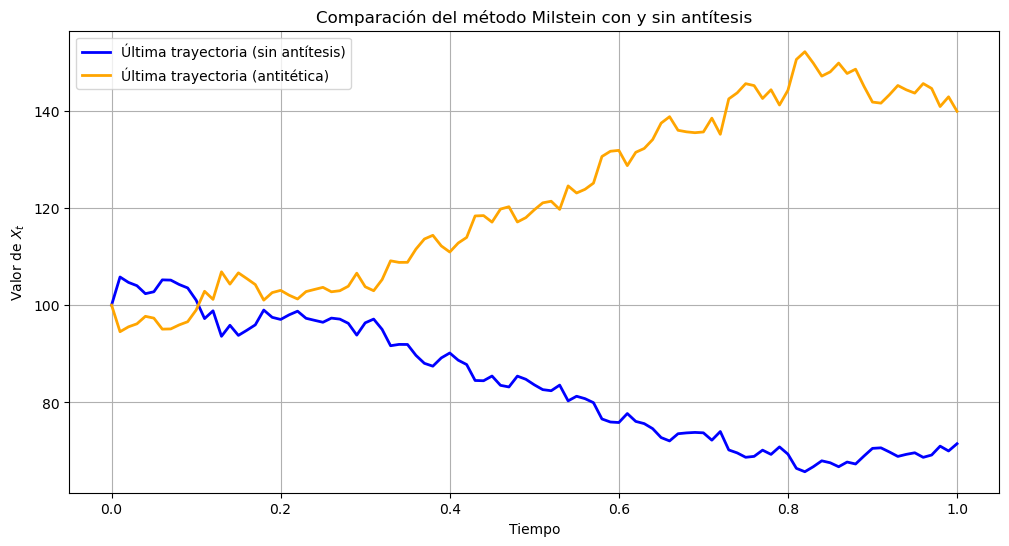

In [19]:
# Función para simular una trayectoria usando el método de Milstein
def simular_milstein(S0, r, sigma, T, dt, antitetico=False):
    N = int(T / dt)  # Número de pasos
    t = np.linspace(0, T, N + 1)  # Vector de tiempos
    S = np.zeros(N + 1)  # Inicialización de la trayectoria estándar
    S[0] = S0  # Condición inicial
    if antitetico:
        S_ant = np.zeros(N + 1)  # Inicialización de la trayectoria antitética
        S_ant[0] = S0

    for i in range(1, N + 1):
        dW = np.sqrt(dt) * np.random.normal()  # Incremento Browniano
        increment = (r - 0.5 * sigma**2) * dt + sigma * dW  # Incremento Milstein
        S[i] = S[i - 1] * np.exp(increment)  # Trayectoria estándar
        if antitetico:
            S_ant[i] = S_ant[i - 1] * np.exp(-increment)  # Trayectoria antitética

    if antitetico:
        return t, S, S_ant
    return t, S

# Parámetros
S0 = 100  # Precio inicial
r = 0.05  # Tasa de interés
sigma = 0.2  # Volatilidad
T = 1  # Tiempo total
dt = 0.01  # Paso de tiempo

# Simulación de una trayectoria con y sin antítesis
t, S, S_ant = simular_milstein(S0, r, sigma, T, dt, antitetico=True)

# Creación del gráfico
plt.figure(figsize=(12, 6))
plt.plot(t, S, label='Última trayectoria (sin antítesis)', color='blue', linewidth=2)
plt.plot(t, S_ant, label='Última trayectoria (antitética)', color='orange', linewidth=2)
plt.title('Comparación del método Milstein con y sin antítesis')
plt.xlabel('Tiempo')
plt.ylabel('Valor de $X_t$')
plt.legend()
plt.grid(True)
plt.show()

## Ejercicio 5: Método antitético con Milstein

Utilizando el modelo: 
$$ dX_t = \mu X_t dt + \sigma X_t dW_t,\hspace{0.3cm} X_0 = x_0$$
donde $W_t$ es un proceso de Wiener estándar, $\mu > 0$ y $\sigma > 0 $

1. Simule $X_t$ usando el método de Milstein para $t \in [0,T]$ con T = 1 y un paso de tiempo $\Delta t = 0.01$. Use los parámetros:
$x_0 = 1$
$\mu = 0.5$
$\sigma = 0.2$


Donde $\Delta W_i = \sqrt{\Delta t_i } Z_{t_i  + 1} \sim N(0,1)$

Y el esquema $$X_{t+i} = X_t + \mu X_t dt + \sigma X_t dW_t + \frac{1}{2} \sigma^2 X_t (dW_{t}^{2} - dt)$$

1. Calculamos el número de pasos como $N = \frac{T}{\Delta t}$
2. Se crea un arreglo para la serie $X_t$ de tamaño N + 1 para almacenar los pasos que se den en la serie.
3. Establecemos el primer valor de la serie como $X_0 = 1$
4. Partimos el intervalo de tiempo [0,1] para ver los pasos que se darán.
5. Se comienza el ciclo para simular el proceso estocástico:
    6. Generamos el incremento de Wiener, con distribución normal, con media cero y varianza $\sqrt{\Delta t}$
    7. Realizamos la forma del proceso de Milstein: $$X_{t+i} = X_t + \mu X_t dt + \sigma X_t dW_t + \frac{1}{2} \sigma^2 X_t (dW_{t}^{2} - dt)$$
    8. En cada iteración se actualiza el paso con el anterior
9. Se gráfica el proceso de la serie $X_t$

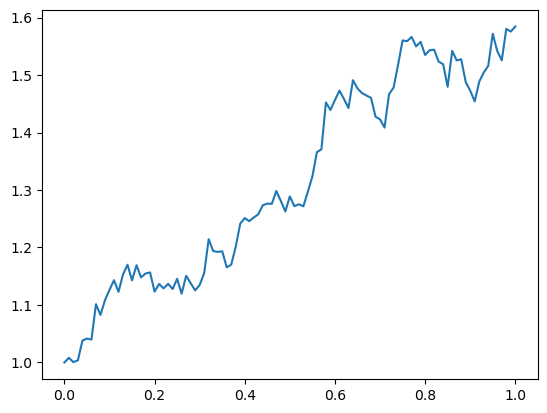

In [180]:

# Método de Milstein
# Parámetros
T = 1
dt = 0.01
x0 = 1
mu = 0.5 
sigma = 0.2 #desviación estándar (volatilidad)
n = int(T/dt)

#Paso 1:
X = np.zeros(n+1)  #Espacios para generar la serie Xt
X[0] = x0    #Valor la entrada 1 del arreglo
t = np.linspace(0,T,n+1)
#Paso 2: Simulación mediante euler
for i in range(n):   
    #dw = np.random.normal(0,1) #Ahora dW se distribuye normal
    dw = np.random.normal(0,np.sqrt(dt)) #Ahora dW se distribuye normal
    X[i+1] = X[i]+(mu * X[i] * dt)+ (sigma * X[i] * dw) + 0.5 * (sigma**2)*X[i] *( dw**2 - dt)

#Gráfico de la trayectoria de Xt con el método de Milstein
plt.plot(t,X)


2. Compare los resultados con el método de Euler-Murayama y analice las diferencias entre las trayectorias simuladas 

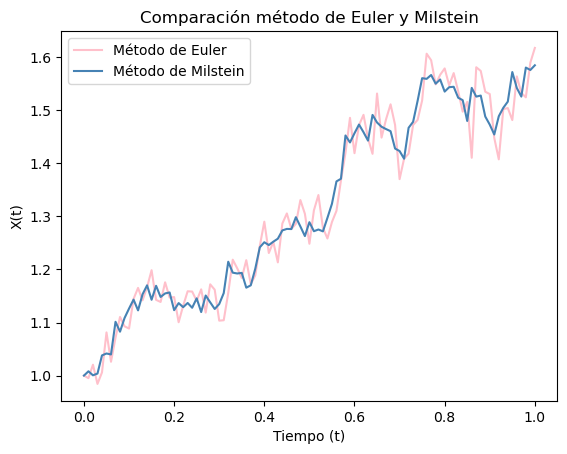

In [182]:
#Gráfico de la trayectoria de Xt con el método de Euler 
#Euler - Maruyama
# Método de Euler
# Parámetros
T = 1
dt = 0.01
x0 = 1
mu = 0.5 
sigma = 0.2 #desviación estándar (volatilidad)
n = int(T/dt)

#Paso 1:
Xe = np.zeros(N+1)  #Espacios para generar la serie Xt
Xe[0] = x0    #Valor la entrada 1 del arreglo
te = np.linspace(0,T,n+1)
#Paso 2: Simulación mediante euler
for i in range(n):   
    dw = np.random.normal(0,np.sqrt(dt))
    Xe[i+1] = X[i]+(mu * X[i] * dt)+ (sigma * X[i] * dw)

#Gráfico de la trayectoria de Xt con el método de Euler-Maruyana
plt.plot(te,Xe, label ='Método de Euler', color = 'pink')
plt.legend()
#Gráfico de la trayectoria de Xt con el método de Milstein
plt.plot(t, X, label = 'Método de Milstein', color = 'steelblue')
plt.title("Comparación método de Euler y Milstein")
plt.xlabel("Tiempo (t)")  # Etiqueta para el eje x
plt.ylabel("X(t)")  # Etiqueta para el eje y
plt.legend()
plt.show()  # Mostrar el gráfico

Se puede observar que la trayectoria de la serie con el método de Euler tiene más picos en las trayectoria. Por el contrario, la serie realizada con el método de Milstein se ve más sueve y tiene menos picos. 

3. Estime el valor esperado $E[X_T]$ y compárelo con la solución teórica:
$$ E[X_T] = x_0 e^{\mu T}$$

1. Calculamos el número de pasos como $N = \frac{T}{\Delta t}$
2. Se crea un arreglo para la serie $X_t$ de tamaño N + 1 para almacenar los pasos que se den en la serie.
3. Establecemos el primer valor de la serie como $X_0 = 1$
4. Partimos el intervalo de tiempo [0,1] para ver los pasos que se darán.
5. Se comienza el ciclo para simular el proceso estocástico:
    6. Generamos el incremento de Wiener, con distribución normal, con media cero y varianza $\sqrt{\Delta t}$
    7. Realizamos la forma del proceso de Milstein: $$X_{t+i} = X_t + \mu X_t dt + \sigma X_t dW_t + \frac{1}{2} \sigma^2 X_t (dW_{t}^{2} - dt)$$
    8. En cada iteración se actualiza el paso con el anterior
9. Se realiza este proceso 10,000 y el último paso de las series generadas se guarda en una lista
10. Se obtiene el promedio de la lista, con los últimos pasos de las series
11. Se obtiene el valor esperado teórico con la ecuación de manera directa y solo sustituyendo los valores

In [211]:
# Método de Milstein
# Parámetros
T = 1
dt = 0.01
x0 = 1
mu = 0.5 
sigma = 0.2 #desviación estándar (volatilidad)
N = int(T/dt)

lista = []
for j in range(10000): #Número de series simuladas
    # Paso 1:
    X = np.zeros(N+1)  #Espacios para generar la serie Xt
    X[0] = x0    #Valor la entrada 1 del arreglo
    t = np.linspace(0,T, N+1) #número de particiones (time)
    #Paso 2: Simulación mediante Milstein
    for i in range(N):   
        #dw = np.random.normal(0,1) #Ahora dW se distribuye normal estándar
        dw = np.random.normal(0,np.sqrt(dt)) #Ahora dW se distribuye normal
        X[i+1] = X[i]+(mu * X[i] * dt)+ (sigma * X[i] * dw) + 0.5 * (sigma**2)*X[i] *( dw**2 - dt)
    lista.append(X[-1])
lista = np.array(lista)
X_media = np.mean(lista)

print(f"Valor esperado simulado de E[X]:", X_media)
#Solución teórica
Teorica = x0 * np.exp(mu*T)
print(f"Valor esperado teórico de de E[X]:", Teorica)

Valor esperado simulado de E[X]: 1.6480994450585327
Valor esperado teórico de de E[X]: 1.6487212707001282


## Ejercicio 6: Método antitético con Milstein

Utilizando el modelo del ejercicio anterior:
1. Implemente el método antitético para reducir la varianza de la estimación. Para cada $W_{t}^{(1)} \sim N(0, \sqrt{\Delta t}$, genere la trayectoria antitética $W_{t}^{(2)} =-W_{t}^{(1)}$

1. Definimos los parámetos: T = 1, dt = 0.01, $x_0 = 1$, $\mu = 0.5$, $\sigma = 0.2$ y $n = \frac{T}{dt}$.
2. Generamos los espacios para la serie $X_t$ y al primer valor le asignamos el 1
3. Generamos la partición del tiempo, en el intervalo [0,1] hasta el tiempo T
4. Comenzamos el ciclo hasta los n pasos, para generar el incremento de Wiener (dW) en cada iteración.
    5. Generamos el incremento de Wiener (dW), el cual se distribuye normal $N \sim       (0, \sqrt{\Delta t})$
    6. Identificamos la parte de la EDE que debemos derivar y aplicamos el método de      
Milstein, lo cual queda de la forma:
    $$X_{t+i} = X_t + \mu X_t dt + \sigma X_t dW_t + \frac{1}{2} \sigma^2 X_t (dW_{t}^{2} - dt)$$ 
7. Para el método antitético generamos otra serie $Y_t$ donde el dw, ahora será negativo.
8. Los últimos pasos de las series se guardan en una lista, hasta tener 10,000 simulaciones 
9. Se obtiene la media de la lista y de la serie $X_t$ que solo guardará los valores de la serie sin el método antitético
10. Se obtiene la varizna de la lista con el método antitético y el de $X_t$

In [222]:
import numpy as np

# Parámetros
T = 1  # Tiempo total
dt = 0.01  # Tamaño del paso
x0 = 1  # Valor inicial
mu = 0.5  # Tasa de crecimiento
sigma = 0.2  # Volatilidad
N = int(T / dt)  # Número de pasos

# Lista para almacenar los resultados
lista = []
lista2 = []
for j in range(10000):  
    # Inicializar series X_t y Y_t
    X = np.zeros(N + 1)
    Y = np.zeros(N + 1)
    X[0] = x0
    Y[0] = x0
    
    # Simulación mediante Milstein con antítesis
    for i in range(N):
        dw = np.random.normal(0, np.sqrt(dt))  # Incremento del proceso de Wiener
        X[i+1] = X[i]+(mu * X[i] * dt)+ (sigma * X[i] * dw) + 0.5 * (sigma**2)*X[i] *( dw**2 - dt)
        Y[i+1] = Y[i]+(mu * Y[i] * dt)- (sigma * Y[i] * dw) + 0.5 * (sigma**2)*Y[i] *( (-dw)**2 - dt)  #Antitético (-dw)
    
    # Agregar los últimos valores de las series simuladas a la lista
    lista2.append(X[-1])
    lista.append(X[-1])
    lista.append(Y[-1])

# Convertir la lista a un arreglo numpy
lista = np.array(lista)
lista2 = np.array(lista2)
# Calcular el valor esperado simulado
X_media = np.mean(lista)
print(f"Valor esperado simulado de E[X]: {X_media}")

# Solución teórica
Teorica = x0 * np.exp(mu * T)
print(f"Valor esperado teórico de E[X]: {Teorica}")

# Calcular valor de la varianza simulado
X_var = np.var(lista2)
X_var_a = np.var(lista)
print(f"Varianza simulaciones: {X_var}")
print(f"Varianza antitética: {X_var_a}")


Valor esperado simulado de E[X]: 1.647105652310137
Valor esperado teórico de E[X]: 1.6487212707001282
Varianza simulaciones: 0.11207686471175693
Varianza antitética: 0.11113108671692389


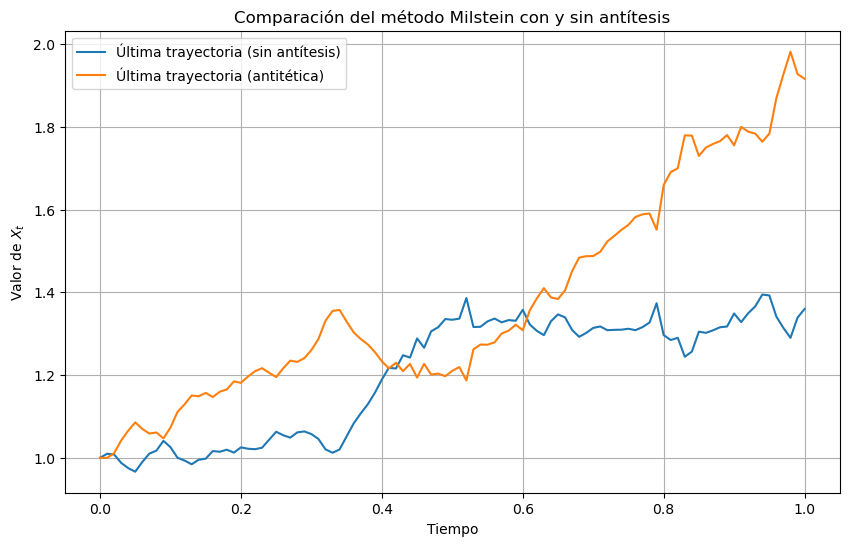

In [224]:
#Gráfico de la trayectoria de Xt con el método de Milstein
t = np.linspace(0, T, N + 1)
plt.figure(figsize=(10, 6))
plt.title("Comparación del método Milstein con y sin antítesis")
plt.plot(t, X, label="Última trayectoria (sin antítesis)")
plt.plot(t, Y, label="Última trayectoria (antitética)")
plt.xlabel("Tiempo")
plt.ylabel("Valor de $X_t$")
plt.legend()
plt.grid()
plt.show()

# Ejercicio 7

El problema plantea simular una ecuación diferencial estocástica (EDE) no lineal con el objetivo de estudiar la dinámica de \(X_t\) bajo la ecuación:

$$
dX_t = (\alpha - \beta X_t^2) dt + \sigma X_t dW_t, \quad X_0 = x_0
$$

donde:
- $(X_t)$ representa el proceso estocástico.
- $(\alpha) y (\beta)$ son parámetros que determinan el comportamiento determinista del sistema.
- $(\sigma)$ controla la intensidad de la componente estocástica.
- $(W_t)$ es un movimiento browniano estándar.


#### Método de Milstein
El método de Milstein mejora la simulación de EDEs al incluir un término adicional para capturar el efecto del ruido cuadrático:

$$
X_{t+\Delta t} = X_t + (\alpha - \beta X_t^2) \Delta t + \sigma X_t \Delta W + \frac{1}{2} \sigma^2 X_t (\Delta W^2 - \Delta t)
$$

Pasos:
1. **Discretización del tiempo:** Se divide el intervalo $[0, T]$ en $N$ pasos con un tamaño $(\Delta t)$.
2. **Inicialización:** Se fija el valor inicial $(X_0 = 0.5)$.
3. **Iteración:** Para cada paso, se calcula $(X_{t+\Delta t})$ usando la fórmula de Milstein, donde $(\Delta W)$ es un incremento browniano generado aleatoriamente.

#### Método Antitético
Para reducir la varianza, se generan trayectorias adicionales usando incrementos opuestos $(-\Delta W)$:
1. Se simula una trayectoria estándar usando $(\Delta W)$.
2. Se genera una trayectoria antitética usando $(-\Delta W)$.
3. Se calcula la trayectoria promedio como:
   $$
   \hat{X}_t = \frac{1}{2} (X_t + X_t^{\text{ant}})
   $$

Esto reduce la varianza al equilibrar los efectos del ruido aleatorio.


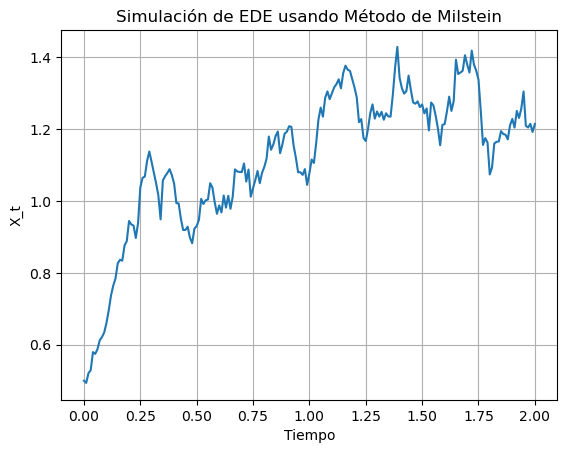

In [20]:
# Función para simular una EDE usando el método de Milstein
def simular_milstein(alpha, beta, sigma, x0, T, dt):
    N = int(T / dt)  # Número de pasos
    t = np.linspace(0, T, N+1)  # Vector de tiempos
    X = np.zeros(N+1)  # Inicialización de la trayectoria
    X[0] = x0  # Condición inicial

    for i in range(N):
        dW = np.sqrt(dt) * np.random.normal()  # Incremento Browniano
        # Actualización de Milstein
        X[i+1] = X[i] + (alpha - beta * X[i]**2) * dt + sigma * X[i] * dW + 0.5 * sigma**2 * X[i] * (dW**2 - dt)

    return t, X

# Parámetros
alpha = 2  # Tasa de crecimiento determinista
beta = 1  # Coeficiente no lineal
sigma = 0.3  # Intensidad del ruido
x0 = 0.5  # Valor inicial
T = 2  # Tiempo total
dt = 0.01  # Tamaño del paso de tiempo

# Simulación
t, X = simular_milstein(alpha, beta, sigma, x0, T, dt)

# Visualización
plt.plot(t, X)  # Graficar la trayectoria
plt.title('Simulación de EDE usando Método de Milstein')  # Título del gráfico
plt.xlabel('Tiempo')  # Etiqueta del eje X
plt.ylabel('X_t')  # Etiqueta del eje Y
plt.grid(True)  # Mostrar cuadrícula
plt.show()

In [21]:
# Función para simular una EDE usando el método de Milstein con antítesis
def simular_milstein_antitetico(alpha, beta, sigma, x0, T, dt):
    N = int(T / dt)  # Número de pasos
    t = np.linspace(0, T, N+1)  # Vector de tiempos
    X = np.zeros(N+1)  # Trayectoria estándar
    X_ant = np.zeros(N+1)  # Trayectoria antitética
    X[0], X_ant[0] = x0, x0  # Condición inicial para ambas trayectorias

    for i in range(N):
        dW = np.sqrt(dt) * np.random.normal()  # Incremento Browniano
        dW_ant = -dW  # Incremento antitético (opuesto)
        
        # Trayectoria estándar
        X[i+1] = X[i] + (alpha - beta * X[i]**2) * dt + sigma * X[i] * dW + 0.5 * sigma**2 * X[i] * (dW**2 - dt)
        # Trayectoria antitética
        X_ant[i+1] = X_ant[i] + (alpha - beta * X_ant[i]**2) * dt + sigma * X_ant[i] * dW_ant + 0.5 * sigma**2 * X_ant[i] * (dW_ant**2 - dt)
    
    # Retornar el promedio de las trayectorias estándar y antitética
    return t, 0.5 * (X + X_ant)

# Simulación usando el método antitético
t, X_antitetico = simular_milstein_antitetico(alpha, beta, sigma, x0, T, dt)

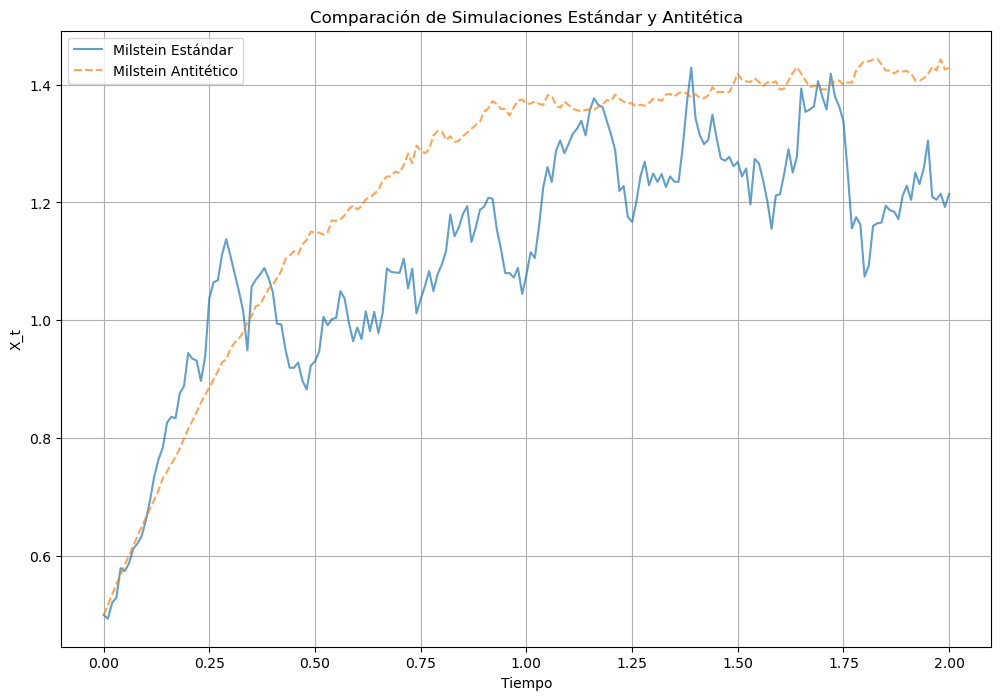

Simulación Estándar - Media: 1.12, Varianza: 0.03850
Método Antitético - Media: 1.23, Varianza: 0.05888


In [22]:
# Visualización de ambas simulaciones
plt.figure(figsize=(12, 8))  # Tamaño de la figura
plt.plot(t, X, label='Milstein Estándar', alpha=0.7)  # Trayectoria estándar
plt.plot(t, X_antitetico, label='Milstein Antitético', alpha=0.7, linestyle='--')  # Trayectoria antitética
plt.title('Comparación de Simulaciones Estándar y Antitética')  # Título del gráfico
plt.xlabel('Tiempo')  # Etiqueta del eje X
plt.ylabel('X_t')  # Etiqueta del eje Y
plt.legend()  # Mostrar leyendas
plt.grid(True)  # Mostrar cuadrícula
plt.show()  # Mostrar el gráfico

# Calculando estadísticas descriptivas
media_estandar = np.mean(X)  # Media de la trayectoria estándar
media_antitetica = np.mean(X_antitetico)  # Media de la trayectoria antitética
varianza_estandar = np.var(X)  # Varianza de la trayectoria estándar
varianza_antitetica = np.var(X_antitetico)  # Varianza de la trayectoria antitética

# Imprimiendo resultados estadísticos
print(f"Simulación Estándar - Media: {media_estandar:.2f}, Varianza: {varianza_estandar:.5f}")
print(f"Método Antitético - Media: {media_antitetica:.2f}, Varianza: {varianza_antitetica:.5f}")

# Ejercicio 8

El precio de la opción $(C)$ está dado por:

$$
C = e^{-rT} \mathbb{E}[(S_T - K)^+],
$$

donde:
- $(S_T)$ es el precio del activo al vencimiento.
- $(K)$ es el precio de ejercicio.
- $(r)$ es la tasa libre de riesgo.
- $(T)$ es el tiempo al vencimiento.
- $[(S_T - K)^+]$ es el valor positivo de $(S_T - K)$, conocido como el **payoff** de la opción.

El precio del activo $(S_t)$ sigue la dinámica del modelo de Black-Scholes:

$$
dS_t = r S_t dt + \sigma S_t dW_t,
$$

donde:
- $(S_0)$ es el precio inicial del activo.
- $(r)$ es la tasa libre de riesgo.
- $(\sigma)$ es la volatilidad.
- $(dW_t)$ es un incremento del movimiento browniano.

#### Método de Milstein
El método de Milstein mejora la simulación de EDEs al incluir un término adicional que captura el efecto del ruido cuadrático:

$$
S_{t+\Delta t} = S_t + r S_t \Delta t + \sigma S_t \Delta W + \frac{1}{2} \sigma^2 S_t (\Delta W^2 - \Delta t),
$$

donde:
- $(\Delta W)$ es un incremento browniano simulado como $\mathcal{N}(0, \sqrt{\Delta t})$.

Pasos del método:
1. Dividir el intervalo de tiempo $[0, T]$ en $N$ pasos con tamaño $(\Delta t)$.
2. Inicializar $(S_0)$ con el precio inicial del activo.
3. Iterar para calcular $(S_{t+\Delta t})$ en cada paso usando la fórmula de Milstein.

#### Método Antitético
Para reducir la varianza, se generan trayectorias adicionales usando incrementos opuestos $(-\Delta W)$:
1. Simular una trayectoria estándar con $(\Delta W)$.
2. Generar una trayectoria antitética con $(-\Delta W)$.
3. Calcular el precio de la opción como el promedio de los pagos en ambas trayectorias:
   $$
   \hat{C} = \frac{1}{2} (C_{\text{estándar}} + C_{\text{antitético}}).
   $$

Esto ayuda a reducir la varianza al compensar los efectos del ruido aleatorio.

---

### Comparación y Estadísticas
1. **Estimaciones del Precio de la Opción:**
   - Se calcula el precio $(C)$ y su varianza en ambos casos (con y sin reducción de varianza).
2. **Gráficos:** 
   - Comparan las trayectorias estándar y antitéticas del precio del activo.
3. **Análisis:** 
   - El método antitético debería tener una varianza menor, manteniendo un precio esperado similar al de la simulación estándar.

In [24]:
# Función para simular una trayectoria usando el método de Milstein
def simular_milstein(S0, r, sigma, T, dt):
    N = int(T / dt)  # Número de pasos
    t = np.linspace(0, T, N)  # Vector de tiempos
    S = np.zeros(N+1)  # Inicialización de la trayectoria
    S[0] = S0  # Precio inicial

    for i in range(1, N+1):
        dW = np.sqrt(dt) * np.random.normal()  # Incremento Browniano
        # Actualización del precio usando el método de Milstein
        S[i] = S[i-1] + r * S[i-1] * dt + sigma * S[i-1] * dW + 0.5 * sigma**2 * S[i-1] * (dW**2 - dt)

    return S

# Parámetros
S0 = 100  # Precio inicial del activo
r = 0.05  # Tasa de interés libre de riesgo
sigma = 0.2  # Volatilidad
T = 1  # Tiempo total de simulación (1 año)
dt = 0.01  # Tamaño del paso de tiempo

# Simulación de una trayectoria
S = simular_milstein(S0, r, sigma, T, dt)

In [25]:
# Función para calcular el precio de la opción
def precio_opcion(S, K, r, T):
    payoffs = np.maximum(S - K, 0)  # Valor del payoff al vencimiento
    return np.exp(-r * T) * np.mean(payoffs)  # Descuento al valor presente

# Función para simular trayectorias y calcular precios de opciones
def simular_precios(S0, K, r, sigma, T, dt, M, antitetico=False):

    precios = []
    for i in range(M):
        # Simular trayectoria estándar
        S = simular_milstein(S0, r, sigma, T, dt)
        if antitetico:
            # Simular trayectoria antitética
            S_ant = simular_milstein(S0, r, sigma, T, dt)
            # Calcular el payoff promedio entre trayectorias estándar y antitética
            payoff = 0.5 * (precio_opcion(S, K, r, T) + precio_opcion(S_ant, K, r, T))
        else:
            # Calcular el payoff estándar
            payoff = precio_opcion(S, K, r, T)
        precios.append(payoff)
    return np.array(precios)

# Parámetros de la simulación
S0 = 100  # Precio inicial del activo
K = 110  # Precio de ejercicio
r = 0.05  # Tasa de interés libre de riesgo
sigma = 0.2  # Volatilidad
T = 1  # Tiempo hasta el vencimiento (1 año)
dt = 0.01  # Tamaño del paso de tiempo

# Simulación de precios con métodos estándar y antitético
precios_estandar = simular_precios(S0, K, r, sigma, T, dt, 10000)
precios_antitetico = simular_precios(S0, K, r, sigma, T, dt, 10000, antitetico=True)

In [26]:
# Cálculo de la media y la varianza para las simulaciones estándar y antitética
media_estandar = np.mean(precios_estandar)  # Media de los precios estándar
varianza_estandar = np.var(precios_estandar)  # Varianza de los precios estándar
media_antitetica = np.mean(precios_antitetico)  # Media de los precios antitéticos
varianza_antitetica = np.var(precios_antitetico)  # Varianza de los precios antitéticos

# Impresión de los resultados
print(f"Simulación Estándar - Media: {media_estandar:.2f}, Varianza: {varianza_estandar:.5f}")
print(f"Método Antitético - Media: {media_antitetica:.2f}, Varianza: {varianza_antitetica:.5f}")


Simulación Estándar - Media: 2.95, Varianza: 28.98930
Método Antitético - Media: 2.83, Varianza: 13.36241


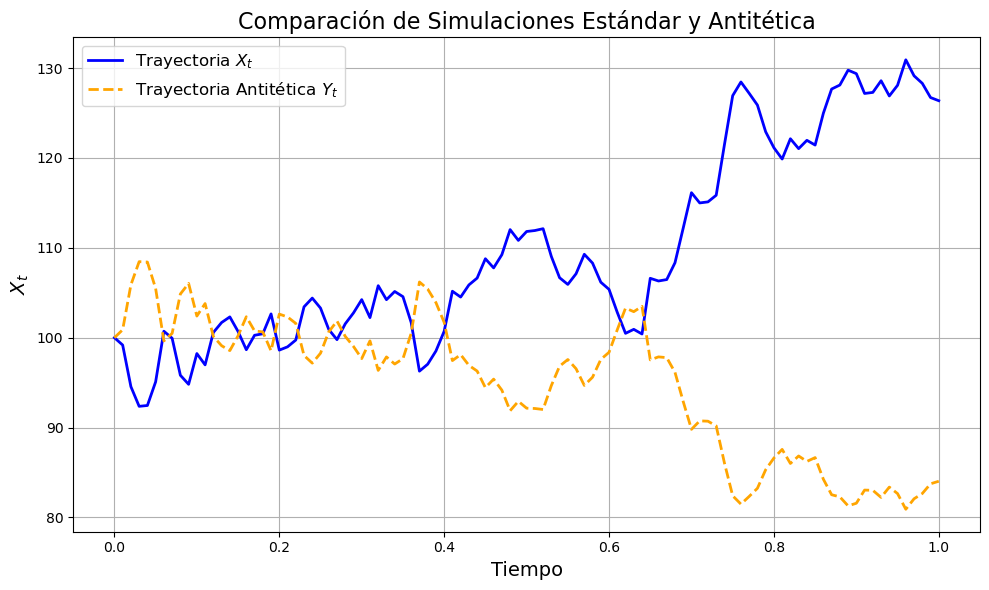

In [28]:
# Función para simular trayectorias usando el método de Milstein con opción antitética
def simular_milstein(S0, r, sigma, T, dt, antitetico=False):
    N = int(T / dt)  # Número de pasos
    t = np.linspace(0, T, N+1)  # Vector de tiempos
    S = np.zeros(N+1)  # Inicialización de la trayectoria estándar
    S[0] = S0  # Precio inicial

    if antitetico:
        Y = np.zeros(N+1)  # Inicialización de la trayectoria antitética
        Y[0] = S0

    for i in range(1, N+1):
        dW = np.sqrt(dt) * np.random.normal()  # Incremento Browniano
        # Actualización estándar
        S[i] = S[i-1] + r * S[i-1] * dt + sigma * S[i-1] * dW + 0.5 * sigma**2 * S[i-1] * (dW**2 - dt)
        if antitetico:
            # Actualización antitética
            Y[i] = Y[i-1] + r * Y[i-1] * dt - sigma * Y[i-1] * dW + 0.5 * sigma**2 * Y[i-1] * (dW**2 - dt)

    if antitetico:
        return t, S, Y  # Retornar las trayectorias estándar y antitética
    return t, S

# Definición de parámetros
S0 = 100  # Precio inicial del activo
K = 110  # Precio de ejercicio
r = 0.05  # Tasa de interés libre de riesgo
sigma = 0.2  # Volatilidad
T = 1  # Tiempo total (1 año)
dt = 0.01  # Tamaño del paso de tiempo

# Visualización de una trayectoria estándar y antitética
t, X, Y = simular_milstein(S0, r, sigma, T, dt, antitetico=True)
plt.figure(figsize=(10, 6))
plt.plot(t, X, label='Trayectoria $X_t$', color='blue', linewidth=2)  # Trayectoria estándar
plt.plot(t, Y, label='Trayectoria Antitética $Y_t$', linestyle='--', color='orange', linewidth=2)  # Trayectoria antitética
plt.title("Comparación de Simulaciones Estándar y Antitética", fontsize=16)  # Título
plt.xlabel("Tiempo", fontsize=14)  # Etiqueta del eje X
plt.ylabel("$X_t$", fontsize=14)  # Etiqueta del eje Y
plt.legend(fontsize=12)  # Leyendas
plt.grid(True)  # Cuadrícula
plt.tight_layout()  # Ajuste del diseño
plt.show()



# Ejercicio 9

Considere la ecuación diferencial estocástica:
$$dX_t = (2X_t - 3 X_{t}^{2})dt + (1+X_t ) dW_t, \hspace{0.3cm} X_0 = x_0$$
donde $x_0 = 0.1$


1. Simule $X_t$ usando el método de Milstein para $t \in [0,1]$ con $\Delta t = 0.005$

La ecuación aplicando el Método de Milstein, la ecuación queda como:
$$dX_t = (2X_t - 3 X_{t}^{2})dt + (1+X_t ) dW_t + 0.5 (1+X_t) \cdot  1 \cdot (dW_{t}^{2} - dt)$$

1. Definimos los parámetos: T = 1, dt = 0.005, $x_0 = 0.1$ y $n = \frac{T}{dt}$.
2. Generamos los espacios para la serie $X_t$ y al primer valor le asignamos el 1
3. Generamos la partición del tiempo, en el intervalo [0,1] hasta el tiempo T
4. Comenzamos el ciclo hasta los n pasos, para generar el incremento de Wiener (dW) en cada iteración.
    5. Generamos el incremento de Wiener (dW), el cual se distribuye normal $N \sim       (0, \sqrt{\Delta t})$
    6. Identificamos la parte de la EDE que debemos derivar y aplicamos el método de      Milstein, lo cual queda de la forma:
    7. $$dX_t = (2X_t - 3 X_{t}^{2})dt + (1+X_t ) dW_t + 0.5 (1+X_t) \cdot  1 \cdot (dW_{t}^{2} - dt)$$. Se guarda cada paso en una lista y se gráfica para ver como          evoluciono en el tiempo.

In [29]:
def simular_milstein(x0, T, dt, antitetico=False, limite=1e3):

    N = int(T / dt)  # Número de pasos
    t = np.linspace(0, T, N+1)  # Vector de tiempos
    X = np.zeros(N+1)  # Inicialización de la trayectoria estándar
    X[0] = x0  # Valor inicial

    if antitetico:
        Y = np.zeros(N+1)  # Inicialización de la trayectoria antitética
        Y[0] = x0

    for i in range(N):
        dw = np.random.normal(0, np.sqrt(dt))  # Incremento Browniano

        # Componente determinista
        f = 2 * X[i] - 3 * X[i]**2

        # Componente estocástica
        g = 1 + X[i]

        # Corrección de Milstein
        correction = 0.5 * g * (dw**2 - dt)

        # Control de valores extremos
        if abs(X[i]) > limite:
            print(f"Valor fuera de rango en el paso {i}, X[i]={X[i]}")
            break

        # Actualización para la trayectoria estándar
        X[i+1] = X[i] + f * dt + g * dw + correction

        if antitetico:
            if abs(Y[i]) > limite:
                print(f"Valor fuera de rango en el paso {i}, Y[i]={Y[i]}")
                break

            # Actualización para la trayectoria antitética
            Y[i+1] = Y[i] + f * dt - g * dw + correction

    if antitetico:
        return t, X, Y  # Retornar las trayectorias estándar y antitética
    return t, X

In [34]:
# Parámetros de la simulación
x0 = 0.1  # Valor inicial de la trayectoria
T = 1  # Tiempo total de simulación
dt = 0.005  # Tamaño del paso de tiempo
iteraciones = 1000  # Número de simulaciones

# Arrays para almacenar los resultados
valores_finales = []  # Valores finales para trayectorias estándar y antitéticas
valores_finales_antiteticos = []  # Solo para trayectorias estándar

# Simulaciones
for _ in range(iteraciones):
    t, X, Y = simular_milstein(x0, T, dt, antitetico=True)  # Simulación con antitético
    valores_finales.append(X[-1])  # Agregar el último valor de la trayectoria estándar
    valores_finales.append(Y[-1])  # Agregar el último valor de la trayectoria antitética
    valores_finales_antiteticos.append(X[-1])  # Solo almacenar trayectorias estándar para comparar

# Calcular estadísticas
media_X = np.mean(valores_finales)  # Media considerando trayectorias estándar y antitéticas
varianza_X = np.var(valores_finales)  # Varianza considerando trayectorias estándar y antitéticas
media_X_antitetico = np.mean(valores_finales_antiteticos)  # Media solo para trayectorias estándar
varianza_X_antitetico = np.var(valores_finales_antiteticos)  # Varianza solo para trayectorias estándar

# Imprimir resultados
print(f"Valor esperado simulado (con antitético): {media_X:.5f}")
print(f"Varianza (con antitético): {varianza_X:.5f}")
print(f"Valor esperado simulado (sin antitético): {media_X_antitetico:.5f}")
print(f"Varianza (sin antitético): {varianza_X_antitetico:.5f}")

Valor fuera de rango en el paso 148, Y[i]=-1016.6412295694314
Valor fuera de rango en el paso 150, X[i]=-2335.588320236731
Valor fuera de rango en el paso 95, X[i]=-2912.6536623062884
Valor fuera de rango en el paso 150, X[i]=-9955.401286423034
Valor fuera de rango en el paso 182, X[i]=-5987.309704929457
Valor fuera de rango en el paso 150, X[i]=-8544.63486245908
Valor fuera de rango en el paso 107, X[i]=-2115.698891055178
Valor fuera de rango en el paso 116, X[i]=-1259.4188169141328
Valor fuera de rango en el paso 164, X[i]=-5203.180815108372
Valor fuera de rango en el paso 128, X[i]=-15313.403167539902
Valor fuera de rango en el paso 176, X[i]=-2762.913103034882
Valor fuera de rango en el paso 127, X[i]=-1021.8240559470562
Valor fuera de rango en el paso 119, X[i]=-8070.913286612298
Valor fuera de rango en el paso 143, X[i]=-1659.502807571344
Valor fuera de rango en el paso 113, X[i]=-9661.583567121406
Valor fuera de rango en el paso 134, X[i]=-1091.3217433648556
Valor fuera de rango

Valor fuera de rango en el paso 128, X[i]=-1645.6214877666464
Valor fuera de rango en el paso 133, X[i]=-9197.894623000477
Valor fuera de rango en el paso 119, X[i]=-13912.491723854802
Valor fuera de rango en el paso 177, X[i]=-1603.7706217986497
Valor fuera de rango en el paso 128, X[i]=-1183.3947867897234
Valor fuera de rango en el paso 138, X[i]=-1532.8591160330477
Valor fuera de rango en el paso 127, X[i]=-14022.680863545223
Valor fuera de rango en el paso 184, X[i]=-2061.20475964023
Valor fuera de rango en el paso 125, X[i]=-14601.282334691568
Valor fuera de rango en el paso 126, X[i]=-1446.582793877159
Valor fuera de rango en el paso 186, X[i]=-6240.7827527489535
Valor fuera de rango en el paso 186, X[i]=-2510.841302379073
Valor fuera de rango en el paso 187, X[i]=-1730.6363393637253
Valor fuera de rango en el paso 140, X[i]=-2387.353352991189
Valor fuera de rango en el paso 176, X[i]=-1090.0304073643197
Valor fuera de rango en el paso 138, X[i]=-7971.676223808209
Valor fuera de 

Valor fuera de rango en el paso 168, X[i]=-3011.713611741846
Valor fuera de rango en el paso 109, X[i]=-6796.74624719901
Valor fuera de rango en el paso 130, X[i]=-1118.858687571304
Valor fuera de rango en el paso 107, X[i]=-5040.34960290218
Valor fuera de rango en el paso 96, X[i]=-2169.1961569868795
Valor fuera de rango en el paso 89, X[i]=-3121.180368628734
Valor fuera de rango en el paso 116, X[i]=-7151.575054458886
Valor fuera de rango en el paso 119, X[i]=-7610.192930889756
Valor fuera de rango en el paso 178, X[i]=-7706.186732453753
Valor fuera de rango en el paso 137, X[i]=-2523.461766911425
Valor fuera de rango en el paso 123, X[i]=-14220.322468633616
Valor fuera de rango en el paso 184, X[i]=-9035.589857203051
Valor fuera de rango en el paso 124, X[i]=-10950.495969966743
Valor fuera de rango en el paso 140, X[i]=-5837.459212851603
Valor fuera de rango en el paso 115, X[i]=-2643.4210337512686
Valor fuera de rango en el paso 135, X[i]=-15847.188217369043
Valor fuera de rango en

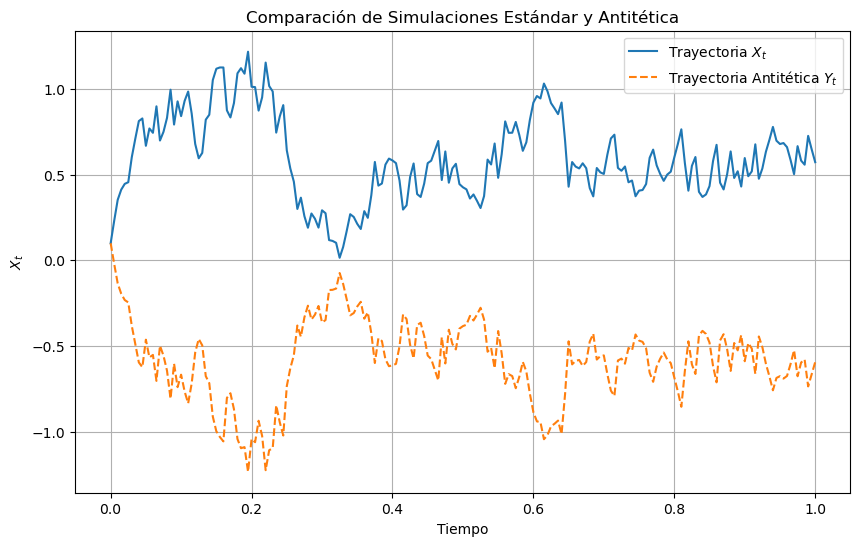

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(t, X, label='Trayectoria $X_t$')
plt.plot(t, Y, label='Trayectoria Antitética $Y_t$', linestyle='--')
plt.title("Comparación de Simulaciones Estándar y Antitética")
plt.xlabel("Tiempo")
plt.ylabel("$X_t$")
plt.legend()
plt.grid(True)
plt.show()

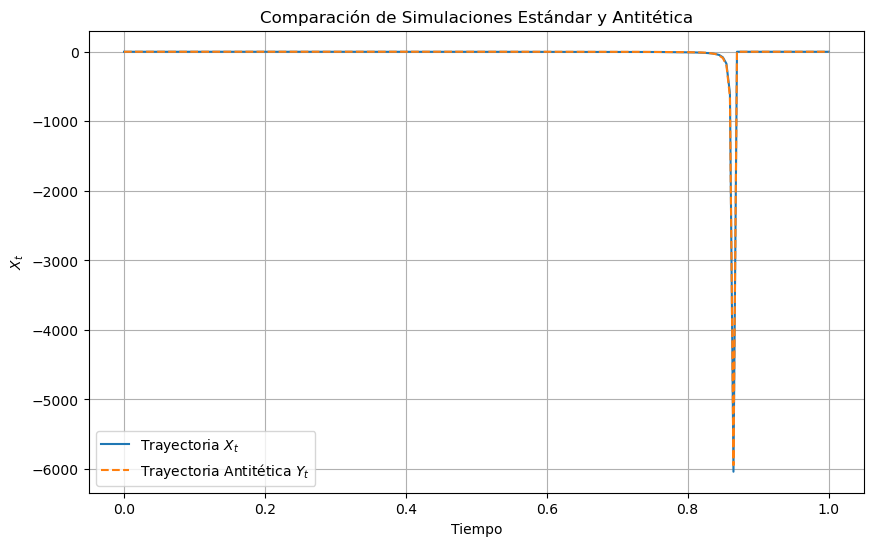

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(t, X, label='Trayectoria $X_t$')
plt.plot(t, Y, label='Trayectoria Antitética $Y_t$', linestyle='--')
plt.title("Comparación de Simulaciones Estándar y Antitética")
plt.xlabel("Tiempo")
plt.ylabel("$X_t$")
plt.legend()
plt.grid(True)
plt.show()

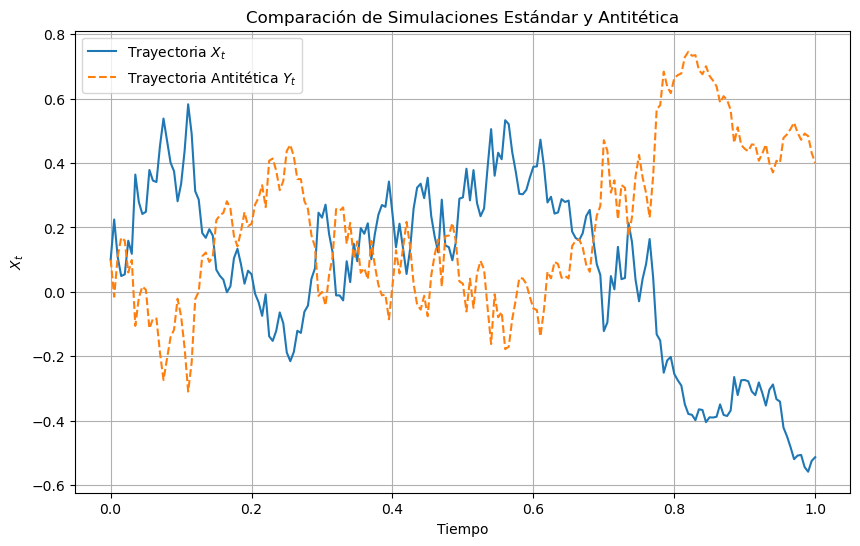

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(t, X, label='Trayectoria $X_t$')
plt.plot(t, Y, label='Trayectoria Antitética $Y_t$', linestyle='--')
plt.title("Comparación de Simulaciones Estándar y Antitética")
plt.xlabel("Tiempo")
plt.ylabel("$X_t$")
plt.legend()
plt.grid(True)
plt.show()